<a href="https://colab.research.google.com/github/Aaditya69Kumar/customer-churn-prediction-capstone-project/blob/main/IDRA_Capstone_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Customer Churn: A Data-Driven Analysis of Subscription Customer Behaviour

**IDRA Capstone Project 2026 — Data Science & AI Training Program**

Project #4 | Task type: **Binary Classification** | Target: `Churn`

---

### Notebook contents

| # | Stage |
|---|---|
| 1 | Setup and environment |
| 2 | Data loading and dataset overview |
| 3 | Data dictionary |
| 4 | Data cleaning |
| 5 | Feature engineering |
| 6 | Exploratory Data Analysis |
| 7 | Statistical analysis |
| 8 | Data preprocessing and train-test preparation |
| 9 | Model training |
| 10 | Model evaluation |
| 11 | Overfitting / underfitting check |
| 12 | Business threshold tuning |
| 13 | Feature importance |
| 14 | Exporting final artefacts |

**Objectives**

1. Quantify the overall churn rate and profile which customer segments leave.
2. Identify the contract, service and billing variables most strongly associated with churn.
3. Validate those associations with appropriate statistical tests rather than eyeballing charts.
4. Build and compare classification models that predict whether a customer will churn.
5. Evaluate using accuracy, precision, recall, F1 and ROC-AUC, and select the metric that matters for retention.
6. Translate the findings into specific retention recommendations.

**Primary research question:** *Can we predict, from contract, service and billing attributes, whether a subscription customer will churn — and which attributes drive that decision?*

## 1. Setup and environment

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Presentation settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

PALETTE = ['#2E86AB', '#E4572E']   # stay / churn
print('Environment ready.')

Environment ready.


## 2. Data loading and dataset overview

**On Google Colab**, upload `Customer-Churn_.csv` and read it directly, or mount Drive.
The `try/except` below lets the same notebook run locally and on Colab without edits.

In [2]:
# --- Colab-friendly loading -------------------------------------------------
CSV_NAME = 'Customer-Churn_.csv'
try:
    df_raw = pd.read_csv(CSV_NAME)
except FileNotFoundError:
    # Fallback paths: Colab upload widget or mounted Drive
    try:
        from google.colab import files
        uploaded = files.upload()
        df_raw = pd.read_csv(next(iter(uploaded)))
    except Exception:
        df_raw = pd.read_csv('/mnt/user-data/uploads/Customer-Churn_.csv')

df = df_raw.copy()
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head()

Saving Customer-Churn .csv to Customer-Churn .csv
Rows: 7,043   Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Structure and memory footprint
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Descriptive statistics for the numeric columns as loaded
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [5]:
# Target balance - this decides which evaluation metric we trust later
target_counts = df['Churn'].value_counts()
target_pct = df['Churn'].value_counts(normalize=True) * 100

overview = pd.DataFrame({'Count': target_counts, 'Percent': target_pct.round(2)})
print(overview)
print(f"\nClass imbalance ratio (Stay : Churn) = {target_counts['No']/target_counts['Yes']:.2f} : 1")

       Count  Percent
Churn                
No      5174    73.46
Yes     1869    26.54

Class imbalance ratio (Stay : Churn) = 2.77 : 1


### Observation

The dataset holds **7,043 customers and 21 columns**. The target `Churn` is imbalanced at roughly
**73.5% Stay / 26.5% Churn**. That imbalance matters: a model that blindly predicts "No churn" for
everyone would already score ~73.5% accuracy while catching zero churners. **Accuracy alone is therefore
not a sufficient metric for this project** — recall on the churn class and ROC-AUC will carry more weight.

## 3. Data dictionary

Documenting variable meaning, type and modelling role before touching the data.

In [6]:
data_dictionary = pd.DataFrame([
    ('customerID',       'Unique customer identifier',                         'Categorical (ID)', 'Dropped - identifier'),
    ('gender',           'Male / Female',                                      'Categorical',      'Feature'),
    ('SeniorCitizen',    'Whether the customer is 65 or older (0/1)',          'Binary',           'Feature'),
    ('Partner',          'Has a partner',                                      'Categorical',      'Feature'),
    ('Dependents',       'Has dependents',                                     'Categorical',      'Feature'),
    ('tenure',           'Months the customer has stayed with the company',    'Numeric (int)',    'Feature'),
    ('PhoneService',     'Subscribed to phone service',                        'Categorical',      'Feature'),
    ('MultipleLines',    'Multiple phone lines',                               'Categorical',      'Feature'),
    ('InternetService',  'DSL / Fiber optic / No',                             'Categorical',      'Feature'),
    ('OnlineSecurity',   'Online security add-on',                             'Categorical',      'Feature'),
    ('OnlineBackup',     'Online backup add-on',                               'Categorical',      'Feature'),
    ('DeviceProtection', 'Device protection add-on',                           'Categorical',      'Feature'),
    ('TechSupport',      'Premium technical support add-on',                   'Categorical',      'Feature'),
    ('StreamingTV',      'Streaming TV add-on',                                'Categorical',      'Feature'),
    ('StreamingMovies',  'Streaming movies add-on',                            'Categorical',      'Feature'),
    ('Contract',         'Month-to-month / One year / Two year',               'Categorical',      'Feature'),
    ('PaperlessBilling', 'Paperless billing enabled',                          'Categorical',      'Feature'),
    ('PaymentMethod',    'How the customer pays',                              'Categorical',      'Feature'),
    ('MonthlyCharges',   'Current monthly bill amount',                        'Numeric (float)',  'Feature'),
    ('TotalCharges',     'Total amount billed over the customer lifetime',     'Numeric (float)',  'Feature'),
    ('Churn',            'Whether the customer left in the last month',        'Binary',           'TARGET'),
], columns=['Variable', 'Description', 'Type', 'Role in this project'])

data_dictionary

,Variable,Description,Type,Role in this project
0,customerID,Unique customer identifier,Categorical (ID),Dropped - identifier
1,gender,Male / Female,Categorical,Feature
2,SeniorCitizen,Whether the customer is 65 or older (0/1),Binary,Feature
3,Partner,Has a partner,Categorical,Feature
4,Dependents,Has dependents,Categorical,Feature
5,tenure,Months the customer has stayed with the company,Numeric (int),Feature
6,PhoneService,Subscribed to phone service,Categorical,Feature
7,MultipleLines,Multiple phone lines,Categorical,Feature
8,InternetService,DSL / Fiber optic / No,Categorical,Feature
9,OnlineSecurity,Online security add-on,Categorical,Feature


## 4. Data cleaning

Each issue below is detected first, then handled, then re-validated — as required by the guide.

In [7]:
# --- 4.1 Missing values ----------------------------------------------------
missing = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
})
print('Declared missing values (NaN):')
print(missing[missing['Missing'] > 0] if missing['Missing'].sum() else '  None reported by pandas.')

Declared missing values (NaN):
  None reported by pandas.


In [8]:
# --- 4.2 Hidden missing values --------------------------------------------
# TotalCharges loaded as object/string, which signals non-numeric entries.
print('TotalCharges dtype as loaded:', df['TotalCharges'].dtype)

blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print(f'Blank (whitespace-only) TotalCharges entries: {blank_mask.sum()}')

# Who are these customers?
df.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'Churn']]

TotalCharges dtype as loaded: object
Blank (whitespace-only) TotalCharges entries: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


**Decision and reasoning.** All 11 blank `TotalCharges` rows belong to customers with `tenure = 0`:
brand-new customers who have not yet been billed a full cycle. The value is not randomly missing — it is
*structurally* zero. Deleting these rows would discard genuine new-customer records, and imputing the
median would falsely imply a long billing history. We therefore convert the column to numeric and set
these 11 values to **0**, which is the factually correct amount billed so far.

In [9]:
# Convert to numeric and impute the structural zeros
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'NaN after coercion: {df["TotalCharges"].isna().sum()}')

df.loc[df['TotalCharges'].isna(), 'TotalCharges'] = 0.0

# Validation
print(f'NaN after treatment: {df["TotalCharges"].isna().sum()}')
print(f'New dtype: {df["TotalCharges"].dtype}')
print(f'Minimum TotalCharges: {df["TotalCharges"].min()}')

NaN after coercion: 11
NaN after treatment: 0
New dtype: float64
Minimum TotalCharges: 0.0


In [10]:
# --- 4.3 Duplicates --------------------------------------------------------
print(f'Fully duplicated rows      : {df.duplicated().sum()}')
print(f'Duplicated customerID values: {df["customerID"].duplicated().sum()}')
print(f'Unique customerIDs          : {df["customerID"].nunique():,} of {len(df):,} rows')

Fully duplicated rows      : 0
Duplicated customerID values: 0
Unique customerIDs          : 7,043 of 7,043 rows


**Finding.** No duplicate rows and no repeated `customerID`. Every row is one unique customer, so no
de-duplication is required. `customerID` is a pure identifier with 7,043 unique values — it carries zero
predictive signal and would only add noise, so it is **dropped before modelling**.

In [11]:
# --- 4.4 Inconsistent category labels --------------------------------------
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    print(f'{col:<20} -> {sorted(df[col].unique())}')

MultipleLines        -> ['No', 'No phone service', 'Yes']
OnlineSecurity       -> ['No', 'No internet service', 'Yes']
OnlineBackup         -> ['No', 'No internet service', 'Yes']
DeviceProtection     -> ['No', 'No internet service', 'Yes']
TechSupport          -> ['No', 'No internet service', 'Yes']
StreamingTV          -> ['No', 'No internet service', 'Yes']
StreamingMovies      -> ['No', 'No internet service', 'Yes']


**Issue.** Seven service columns carry three labels where two would do: `'No internet service'` and
`'No phone service'` both mean exactly the same thing as `'No'` for the purpose of "does this customer
have the add-on?". Keeping them separate would create redundant dummy columns that duplicate information
already held in `InternetService` and `PhoneService`, inflating dimensionality and multicollinearity.

**Decision.** Collapse both variants into `'No'`.

In [12]:
# Standardise the redundant labels
for col in service_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Validation
print('After standardisation:')
for col in service_cols:
    print(f'{col:<20} -> {sorted(df[col].unique())}')

After standardisation:
MultipleLines        -> ['No', 'Yes']
OnlineSecurity       -> ['No', 'Yes']
OnlineBackup         -> ['No', 'Yes']
DeviceProtection     -> ['No', 'Yes']
TechSupport          -> ['No', 'Yes']
StreamingTV          -> ['No', 'Yes']
StreamingMovies      -> ['No', 'Yes']


In [13]:
# --- 4.5 Data types --------------------------------------------------------
# SeniorCitizen is stored as 0/1 int but is conceptually categorical.
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print(df['SeniorCitizen'].value_counts())

# Whitespace / casing check across all text columns
text_cols = df.select_dtypes(include=['object', 'string']).columns
issues = {c: int((df[c].astype(str) != df[c].astype(str).str.strip()).sum()) for c in text_cols}
print('\nColumns with leading/trailing whitespace:',
      {k: v for k, v in issues.items() if v > 0} or 'None')

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

Columns with leading/trailing whitespace: None


In [14]:
# --- 4.6 Invalid / impossible values ---------------------------------------
checks = {
    'tenure < 0'                     : (df['tenure'] < 0).sum(),
    'tenure > 72 (dataset horizon)'  : (df['tenure'] > 72).sum(),
    'MonthlyCharges <= 0'            : (df['MonthlyCharges'] <= 0).sum(),
    'TotalCharges < 0'               : (df['TotalCharges'] < 0).sum(),
    'TotalCharges < MonthlyCharges & tenure>1': ((df['TotalCharges'] < df['MonthlyCharges']) & (df['tenure'] > 1)).sum(),
}
pd.Series(checks, name='Violations').to_frame()

,Violations
tenure < 0,0
tenure > 72 (dataset horizon),0
MonthlyCharges <= 0,0
TotalCharges < 0,0
TotalCharges < MonthlyCharges & tenure>1,0


In [15]:
# --- 4.7 Outlier assessment (IQR rule) -------------------------------------
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
rows = []
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    rows.append([col, round(q1,2), round(q3,2), round(iqr,2), round(lo,2), round(hi,2),
                 n_out, round(n_out/len(df)*100, 2)])

pd.DataFrame(rows, columns=['Variable','Q1','Q3','IQR','Lower bound','Upper bound',
                            'Outliers','Outlier %'])

,Variable,Q1,Q3,IQR,Lower bound,Upper bound,Outliers,Outlier %
0,tenure,9.00,55.00,46.00,-60.00,124.00,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0,0.0
2,TotalCharges,398.55,3786.60,3388.05,-4683.52,8868.67,0,0.0


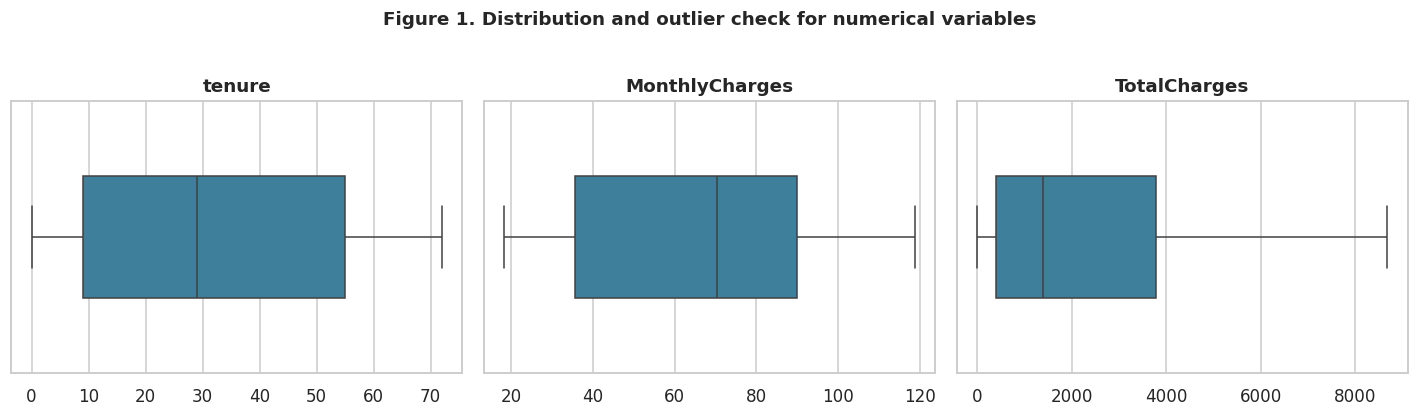

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax, color='#2E86AB', width=0.45)
    ax.set_title(col)
    ax.set_xlabel('')
fig.suptitle('Figure 1. Distribution and outlier check for numerical variables', y=1.04, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Decision on outliers.** The IQR rule flags **no outliers** in `tenure`, `MonthlyCharges` or
`TotalCharges`. `TotalCharges` is right-skewed simply because it is the product of tenure and monthly
charge — long-standing customers legitimately accumulate large totals. These are real, valid customers,
not data-entry errors, and removing them would delete exactly the loyal segment we want the model to
recognise. **No outliers are removed or capped.** The skew is handled instead by scaling during
preprocessing.

In [17]:
# --- 4.8 Post-cleaning validation summary ----------------------------------
summary = pd.DataFrame({
    'Check': ['Rows', 'Columns', 'Missing values', 'Duplicate rows',
              'Non-numeric in TotalCharges', 'Redundant service labels', 'Invalid values'],
    'Before': [df_raw.shape[0], df_raw.shape[1], 11, 0, 11, 'Yes (7 columns)', 0],
    'After' : [df.shape[0], df.shape[1], int(df.isna().sum().sum()), int(df.duplicated().sum()),
               0, 'No', 0]
})
summary

,Check,Before,After
0,Rows,7043,7043
1,Columns,21,21
2,Missing values,11,0
3,Duplicate rows,0,0
4,Non-numeric in TotalCharges,11,0
5,Redundant service labels,Yes (7 columns),No
6,Invalid values,0,0


### Cleaning outcome

**No rows were lost.** All 7,043 customers are retained. The dataset was already in good condition;
the substantive fixes were the `TotalCharges` type coercion with structural-zero imputation, the
consolidation of redundant service labels, and recasting `SeniorCitizen` as categorical.

## 5. Feature engineering

Three features are derived from existing columns because domain reasoning suggests they capture churn
behaviour better than the raw fields alone. All are computed from information available *at the time of
prediction*, so none of them leak the outcome.

In [18]:
# 5.1 Tenure bands - churn risk is known to be lifecycle-dependent, not linear
df['TenureGroup'] = pd.cut(df['tenure'],
                           bins=[-1, 12, 24, 48, 72],
                           labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'])

# 5.2 Count of value-added services subscribed (engagement proxy)
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServices'] = (df[addon_cols] == 'Yes').sum(axis=1)

# 5.3 Average spend per month of tenure vs current bill
#     A ratio > 1 means the customer's bill has risen above their historical average -> price shock.
df['AvgMonthlySpend'] = np.where(df['tenure'] > 0, df['TotalCharges'] / df['tenure'], df['MonthlyCharges'])
df['ChargeRatio'] = df['MonthlyCharges'] / df['AvgMonthlySpend'].replace(0, np.nan)
df['ChargeRatio'] = df['ChargeRatio'].fillna(1.0)

# Binary target encoding for analysis and modelling
df['Churn_flag'] = (df['Churn'] == 'Yes').astype(int)

print('Engineered features created.')
df[['tenure','TenureGroup','NumServices','MonthlyCharges','AvgMonthlySpend','ChargeRatio','Churn_flag']].head()

Engineered features created.


,tenure,TenureGroup,NumServices,MonthlyCharges,AvgMonthlySpend,ChargeRatio,Churn_flag
0,1,0-12 months,1,29.85,29.850000,1.000000,0
1,34,25-48 months,2,56.95,55.573529,1.024768,0
2,2,0-12 months,2,53.85,54.075000,0.995839,1
3,45,25-48 months,3,42.30,40.905556,1.034089,0
4,2,0-12 months,0,70.70,75.825000,0.932410,1


## 6. Exploratory Data Analysis

Each figure below answers one of the research questions. Charts that did not support a conclusion were
left out rather than included for volume.

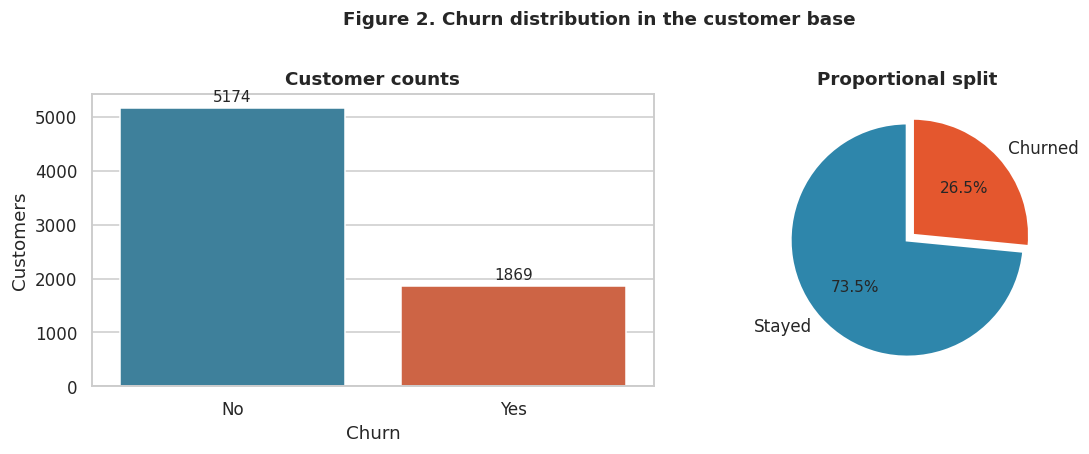

Overall churn rate: 26.54%


In [19]:
# --- Figure 2: Target distribution ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=df, x='Churn', hue='Churn', palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title('Customer counts')
axes[0].set_ylabel('Customers')
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%d', padding=2)

axes[1].pie(df['Churn'].value_counts(), labels=['Stayed', 'Churned'], autopct='%1.1f%%',
            colors=PALETTE, startangle=90, explode=(0, 0.06),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportional split')

fig.suptitle('Figure 2. Churn distribution in the customer base', y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Overall churn rate: {df['Churn_flag'].mean()*100:.2f}%")

**Figure 2 interpretation.** 1,869 of 7,043 customers (26.54%) churned. Roughly one in four
subscribers left in the observation month — commercially significant, and imbalanced enough that the
modelling section must not rely on raw accuracy.

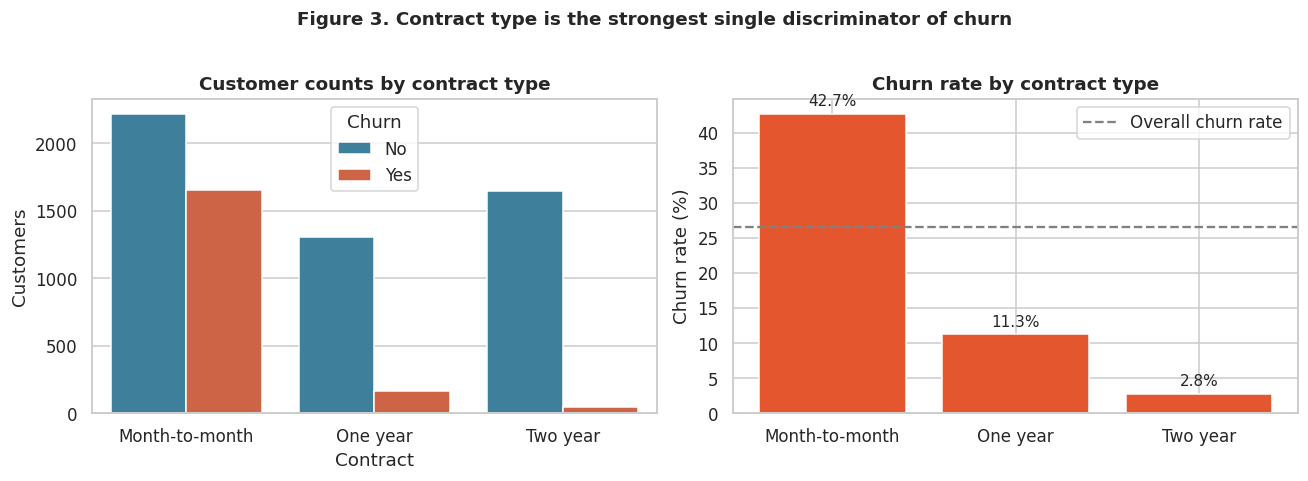

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83


In [20]:
# --- Figure 3: Contract type vs churn -------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.countplot(data=df, x='Contract', hue='Churn', palette=PALETTE, ax=axes[0])
axes[0].set_title('Customer counts by contract type')
axes[0].set_ylabel('Customers')

rate = df.groupby('Contract', observed=True)['Churn_flag'].mean().mul(100).sort_values(ascending=False)
bars = axes[1].bar(rate.index, rate.values, color='#E4572E')
axes[1].bar_label(bars, fmt='%.1f%%', padding=3)
axes[1].axhline(df['Churn_flag'].mean()*100, ls='--', c='grey', label='Overall churn rate')
axes[1].set_title('Churn rate by contract type'); axes[1].set_ylabel('Churn rate (%)')
axes[1].legend()

fig.suptitle('Figure 3. Contract type is the strongest single discriminator of churn',
             y=1.03, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(rate.round(2).to_string())

**Figure 3 interpretation.** Month-to-month customers churn at **42.7%**, against 11.3% on one-year
and just 2.8% on two-year contracts — a **15-fold** difference between the extremes. Contract length is
the single most informative variable in the dataset and is retained as a core predictor.

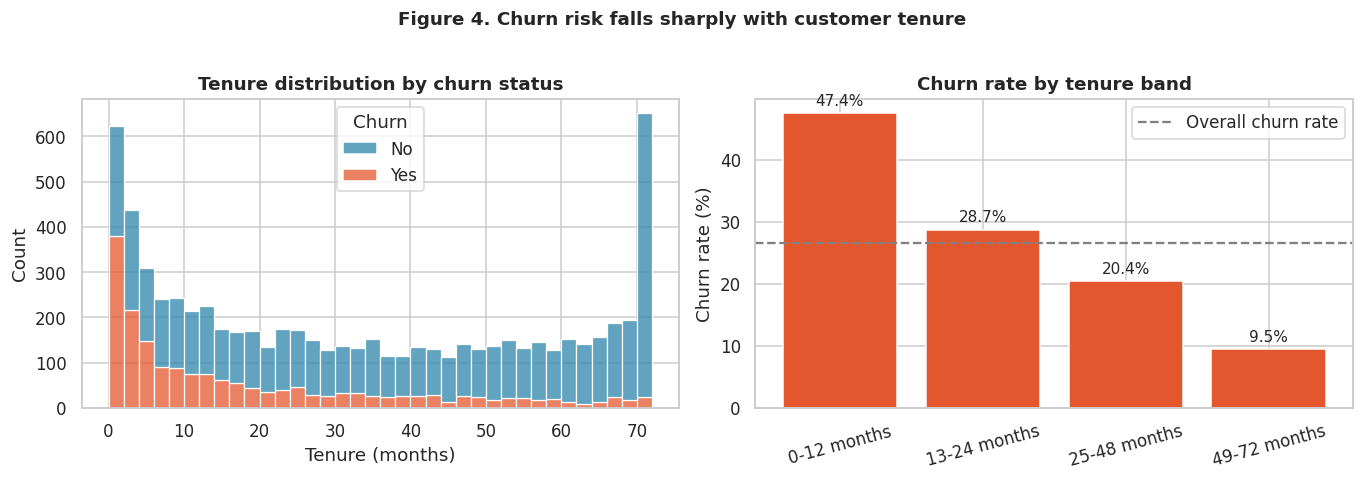

TenureGroup
0-12 months     47.44
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51

Median tenure - churned : 10 months
Median tenure - retained: 38 months


In [21]:
# --- Figure 4: Tenure lifecycle -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

sns.histplot(data=df, x='tenure', hue='Churn', bins=36, multiple='stack',
             palette=PALETTE, ax=axes[0])
axes[0].set_title('Tenure distribution by churn status')
axes[0].set_xlabel('Tenure (months)')

tg = df.groupby('TenureGroup', observed=True)['Churn_flag'].mean().mul(100)
bars = axes[1].bar(tg.index.astype(str), tg.values, color='#E4572E')
axes[1].bar_label(bars, fmt='%.1f%%', padding=3)
axes[1].axhline(df['Churn_flag'].mean()*100, ls='--', c='grey', label='Overall churn rate')
axes[1].set_title('Churn rate by tenure band'); axes[1].set_ylabel('Churn rate (%)')
axes[1].tick_params(axis='x', rotation=15); axes[1].legend()

fig.suptitle('Figure 4. Churn risk falls sharply with customer tenure',
             y=1.03, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(tg.round(2).to_string())
print(f"\nMedian tenure - churned : {df.loc[df.Churn_flag==1,'tenure'].median():.0f} months")
print(f"Median tenure - retained: {df.loc[df.Churn_flag==0,'tenure'].median():.0f} months")

**Figure 4 interpretation.** Churn is heavily front-loaded: **47.4%** of customers in their first
12 months leave, falling to 28.7%, 20.4% and 9.5% in later bands. Median tenure among churners is
10 months versus 38 months for retained customers. The first year is the critical retention window, which
directly supports an early-lifecycle intervention recommendation.

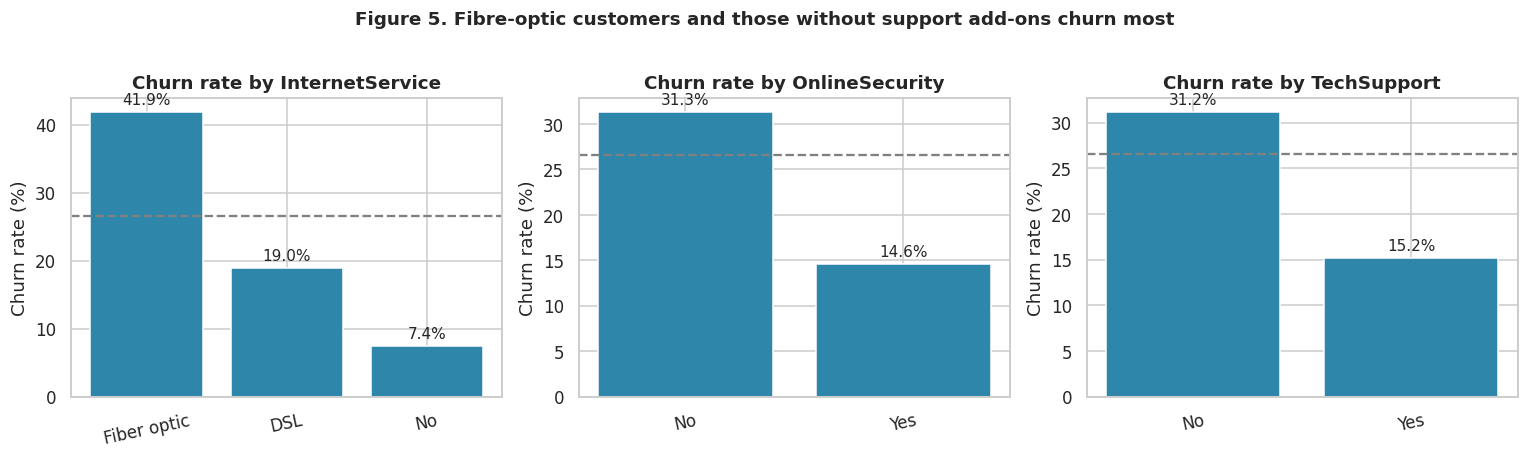

In [22]:
# --- Figure 5: Internet service and add-on protection ---------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['InternetService', 'OnlineSecurity', 'TechSupport']):
    r = df.groupby(col, observed=True)['Churn_flag'].mean().mul(100).sort_values(ascending=False)
    b = ax.bar(r.index.astype(str), r.values, color='#2E86AB')
    ax.bar_label(b, fmt='%.1f%%', padding=3)
    ax.axhline(df['Churn_flag'].mean()*100, ls='--', c='grey')
    ax.set_title(f'Churn rate by {col}'); ax.set_ylabel('Churn rate (%)')
    ax.tick_params(axis='x', rotation=12)

fig.suptitle('Figure 5. Fibre-optic customers and those without support add-ons churn most',
             y=1.03, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Figure 5 interpretation.** Fibre-optic subscribers churn at **41.9%** versus 19.0% for DSL and
7.4% for customers with no internet — despite fibre being the premium product. Customers *without*
`OnlineSecurity` churn at **31.3%** versus 14.6% for those who have it, and `TechSupport` shows an almost
identical pattern (31.2% vs 15.2%) — roughly double the rate. Two readings are plausible: the add-ons create switching friction and perceived value, or customers
who buy them are simply more committed. Either way both variables are strong predictors and are retained.

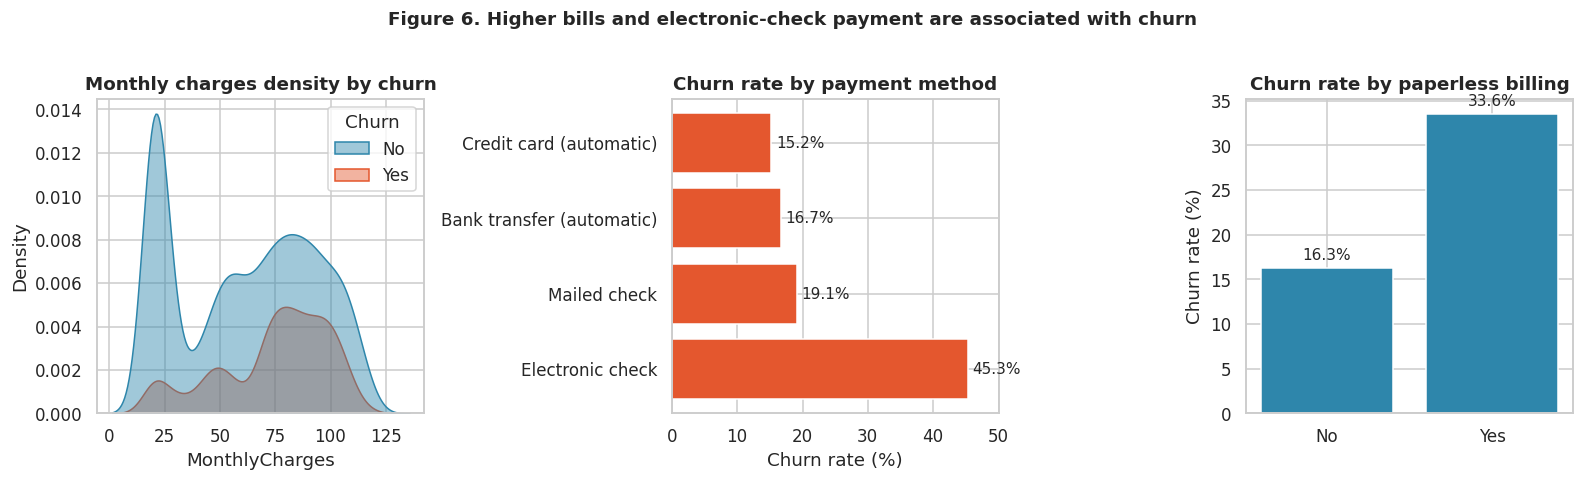

      MonthlyCharges        TotalCharges          tenure        NumServices       
                mean median         mean   median   mean median        mean median
Churn                                                                             
No             61.27  64.43      2549.91  1679.52  37.57   38.0        2.14    2.0
Yes            74.44  79.65      1531.80   703.55  17.98   10.0        1.77    2.0


In [23]:
# --- Figure 6: Billing behaviour ------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, alpha=0.45,
            palette=PALETTE, ax=axes[0])
axes[0].set_title('Monthly charges density by churn')

r = df.groupby('PaymentMethod', observed=True)['Churn_flag'].mean().mul(100).sort_values(ascending=False)
b = axes[1].barh(r.index.astype(str), r.values, color='#E4572E')
axes[1].bar_label(b, fmt='%.1f%%', padding=3)
axes[1].set_title('Churn rate by payment method'); axes[1].set_xlabel('Churn rate (%)')
axes[1].set_xlim(0, 50)

r2 = df.groupby('PaperlessBilling', observed=True)['Churn_flag'].mean().mul(100)
b2 = axes[2].bar(r2.index.astype(str), r2.values, color='#2E86AB')
axes[2].bar_label(b2, fmt='%.1f%%', padding=3)
axes[2].set_title('Churn rate by paperless billing'); axes[2].set_ylabel('Churn rate (%)')

fig.suptitle('Figure 6. Higher bills and electronic-check payment are associated with churn',
             y=1.03, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(df.groupby('Churn', observed=True)[['MonthlyCharges','TotalCharges','tenure','NumServices']]
        .agg(['mean','median']).round(2))

**Figure 6 interpretation.** Churners pay a higher mean monthly charge (₹/$ 74.4 vs 61.3) and the
density plot shows churn concentrated in the 70–105 band. **Electronic check** users churn at 45.3% —
far above automatic bank transfer (16.7%) and credit card (15.2%). A manual, friction-heavy payment
method plausibly signals lower commitment and gives customers a recurring moment to reconsider.

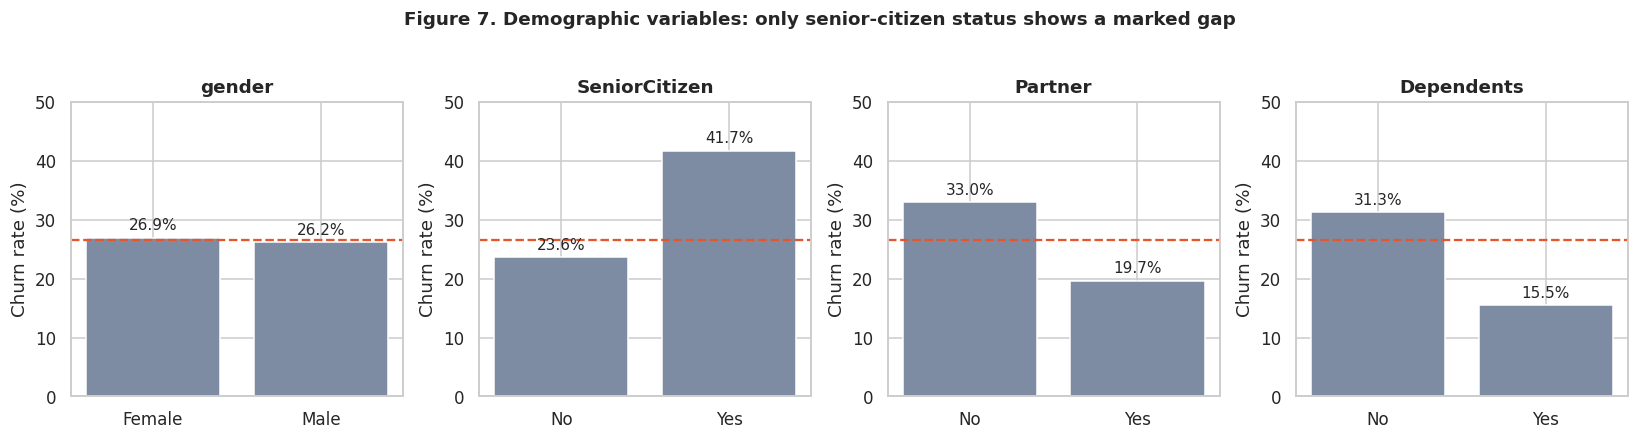

In [24]:
# --- Figure 7: Demographics ------------------------------------------------
demo = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, col in zip(axes, demo):
    r = df.groupby(col, observed=True)['Churn_flag'].mean().mul(100)
    b = ax.bar(r.index.astype(str), r.values, color='#7D8CA3')
    ax.bar_label(b, fmt='%.1f%%', padding=3)
    ax.axhline(df['Churn_flag'].mean()*100, ls='--', c='#E4572E')
    ax.set_title(col); ax.set_ylabel('Churn rate (%)'); ax.set_ylim(0, 50)

fig.suptitle('Figure 7. Demographic variables: only senior-citizen status shows a marked gap',
             y=1.04, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Figure 7 interpretation.** Gender is effectively irrelevant (26.9% vs 26.2%). Senior citizens churn
at 41.7% against 23.6% for non-seniors, and customers without a partner or without dependents churn more.
Gender is kept in the feature set only so the model can confirm its irrelevance through its own
importance ranking rather than being excluded by assumption.

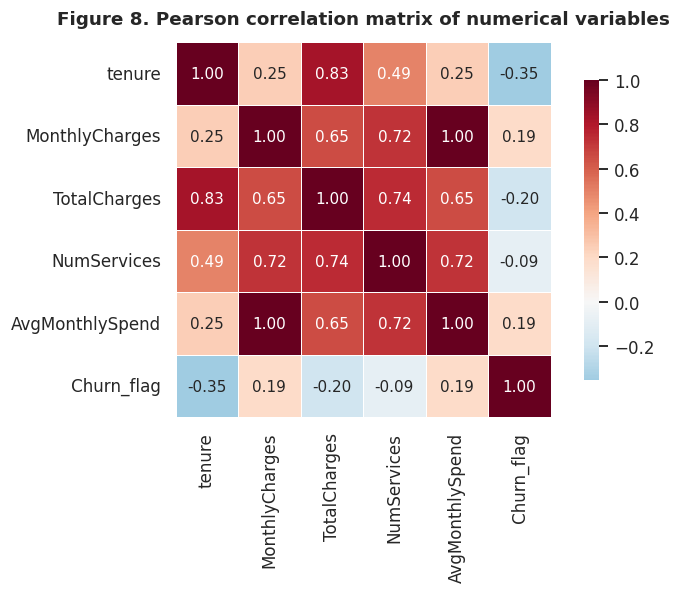

Correlation with churn:
tenure            -0.352
TotalCharges      -0.198
NumServices       -0.088
AvgMonthlySpend    0.193
MonthlyCharges     0.193


In [25]:
# --- Figure 8: Correlation among numerical features -----------------------
num_feats = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'AvgMonthlySpend', 'Churn_flag']
corr = df[num_feats].corr()

plt.figure(figsize=(7.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=.6, cbar_kws={'shrink': .8})
plt.title('Figure 8. Pearson correlation matrix of numerical variables', fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

print('Correlation with churn:')
print(corr['Churn_flag'].drop('Churn_flag').sort_values().round(3).to_string())

**Figure 8 interpretation.** `tenure` has the strongest negative correlation with churn (**-0.35**),
`MonthlyCharges` a mild positive one (+0.19). Note the near-perfect correlation between `tenure` and
`TotalCharges` (**0.83**) — expected, since total charges are mechanically tenure × monthly charge. This
multicollinearity inflates coefficient variance in logistic regression; it is a known limitation, disclosed
in the report's Limitations section, and is the reason coefficient magnitudes are interpreted with caution
while tree-based importance is used as a cross-check.

## 7. Statistical analysis

EDA charts suggest relationships. This section tests whether they are statistically significant rather
than artefacts of sampling.

- **Chi-square test of independence** for categorical predictors vs churn, with **Cramér's V** as an
  effect-size measure (significance alone is cheap at n = 7,043).
- **Welch's t-test** and the non-parametric **Mann-Whitney U** for numerical predictors, since the
  distributions are skewed and variances differ between groups.

In [26]:
# --- 7.1 Chi-square + Cramer's V for every categorical predictor ----------
def cramers_v(confusion):
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    r, k = confusion.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

cat_cols = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines',
            'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
            'StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','TenureGroup']

rows = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rows.append([col, round(chi2, 2), p, dof, round(cramers_v(ct), 3),
                 'Significant' if p < 0.05 else 'Not significant'])

chi_results = (pd.DataFrame(rows, columns=['Variable','Chi-square','p-value','df',"Cramer's V",'Result'])
                 .sort_values("Cramer's V", ascending=False)
                 .reset_index(drop=True))
chi_results['p-value'] = chi_results['p-value'].apply(lambda p: f'{p:.3e}' if p < 0.001 else f'{p:.4f}')
chi_results

,Variable,Chi-square,p-value,df,Cramer's V,Result
0,Contract,1184.60,5.863e-258,2,0.410,Significant
1,TenureGroup,856.10,2.944e-185,3,0.349,Significant
2,InternetService,732.31,9.572e-160,2,0.322,Significant
3,PaymentMethod,648.14,3.682e-140,3,0.303,Significant
4,PaperlessBilling,258.28,4.073e-58,1,0.191,Significant
5,OnlineSecurity,205.63,1.232e-46,1,0.171,Significant
6,Dependents,189.13,4.925e-43,1,0.164,Significant
7,TechSupport,190.17,2.924e-43,1,0.164,Significant
8,SeniorCitizen,159.43,1.510e-36,1,0.150,Significant
9,Partner,158.73,2.140e-36,1,0.150,Significant


**Table interpretation.** At α = 0.05, every categorical variable except **gender** (p = 0.487) and
**PhoneService** (p = 0.339) is significantly associated with churn. Effect sizes tell the more useful
story: `Contract` (V = 0.41) and `TenureGroup` (V = 0.34) are moderate-to-strong, `InternetService` is moderate
(V = 0.32), while `OnlineSecurity` (0.17) and `TechSupport` (0.16) are weaker. Most remaining variables are significant but
weak (V < 0.2) — a reminder that with 7,043 observations, trivial differences still clear the p < 0.05 bar.

In [27]:
# --- 7.2 Numerical variables: group comparison tests ----------------------
rows = []
for col in ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']:
    a = df.loc[df.Churn_flag == 1, col]
    b = df.loc[df.Churn_flag == 0, col]
    t, p_t = stats.ttest_ind(a, b, equal_var=False)          # Welch
    u, p_u = stats.mannwhitneyu(a, b, alternative='two-sided')
    pooled_sd = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    cohens_d = (a.mean() - b.mean()) / pooled_sd
    rows.append([col, round(a.mean(),2), round(b.mean(),2), round(a.median(),2), round(b.median(),2),
                 round(t,2), p_t, p_u, round(cohens_d,3)])

num_tests = pd.DataFrame(rows, columns=['Variable','Mean (churn)','Mean (stay)','Median (churn)',
                                        'Median (stay)','t-statistic','p (Welch t)','p (Mann-Whitney)',
                                        "Cohen's d"])
for c in ['p (Welch t)', 'p (Mann-Whitney)']:
    num_tests[c] = num_tests[c].apply(lambda p: f'{p:.3e}' if p < 0.001 else f'{p:.4f}')
num_tests

,Variable,Mean (churn),Mean (stay),Median (churn),Median (stay),t-statistic,p (Welch t),p (Mann-Whitney),Cohen's d
0,tenure,17.98,37.57,10.00,38.00,-34.82,1.195e-232,2.420e-208,-0.893
1,MonthlyCharges,74.44,61.27,79.65,64.43,18.41,8.592e-73,3.312e-54,0.470
2,TotalCharges,1531.80,2549.91,703.55,1679.53,-18.71,5.903e-75,5.685e-83,-0.480
3,NumServices,1.77,2.14,2.00,2.00,-8.34,9.555e-17,4.735e-07,-0.211


**Interpretation.** All four numerical variables differ significantly between churners and non-churners
under both the parametric and non-parametric test, so the conclusion does not depend on a normality
assumption. Effect sizes: `tenure` shows a large negative effect (Cohen's d ≈ -0.89), while
`TotalCharges` (-0.48) and `MonthlyCharges` (+0.47) show small-to-moderate effects.

**Caution on interpretation.** These tests establish *association*, not causation. Fibre-optic service
being associated with churn does not prove fibre causes churn — price, service reliability and customer
segment are all plausible confounders that this observational dataset cannot separate.

In [28]:
# --- 7.3 Descriptive statistics summary (report Table) --------------------
desc = df[['tenure','MonthlyCharges','TotalCharges','NumServices']].agg(
    ['count','mean','median','std','var','min','max']).T
desc['IQR'] = df[['tenure','MonthlyCharges','TotalCharges','NumServices']].quantile(.75) -               df[['tenure','MonthlyCharges','TotalCharges','NumServices']].quantile(.25)
desc['skew'] = df[['tenure','MonthlyCharges','TotalCharges','NumServices']].skew()
desc.round(2)

,count,mean,median,std,var,min,max,IQR,skew
tenure,7043.0,32.37,29.00,24.56,603.17,0.00,72.00,46.00,0.24
MonthlyCharges,7043.0,64.76,70.35,30.09,905.41,18.25,118.75,54.35,-0.22
TotalCharges,7043.0,2279.73,1394.55,2266.79,5138357.17,0.00,8684.80,3388.05,0.96
NumServices,7043.0,2.04,2.00,1.85,3.41,0.00,6.00,3.00,0.45


**Note on centre.** `TotalCharges` is strongly right-skewed (skew ≈ 0.96) with mean 2,279 well above
median 1,394. For this variable the **median** is the more representative measure of a typical customer.
`tenure` is bimodal (large clusters of very new and very long-standing customers), so neither mean nor
median describes it well on its own — which is precisely why the banded `TenureGroup` feature was created.

## 8. Data preprocessing and train-test preparation

**Task definition.** The target `Churn` takes two values (Yes / No), so this is a **binary classification**
problem — not regression.

**Leakage control.** `customerID` is dropped (identifier, no signal). `Churn_flag` is the encoded target and
must not appear among the features. No column in this dataset records post-outcome information such as a
cancellation date or exit survey, so there is no hidden leakage path.

**Order of operations.** The split happens **before** any scaler or encoder is fitted. All transformations
are wrapped in a `Pipeline` with a `ColumnTransformer`, which guarantees that means, standard deviations
and category levels are learned from training data only and then applied to the test set. This is the
mechanism that prevents data leakage across the split and during cross-validation.

In [29]:
# --- 8.1 Feature / target separation --------------------------------------
DROP_COLS = ['customerID', 'Churn', 'Churn_flag']

X = df.drop(columns=DROP_COLS).copy()
y = df['Churn_flag'].copy()

# Categorical dtype -> string so the encoder handles it uniformly
X['TenureGroup'] = X['TenureGroup'].astype(str)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f'Total features: {X.shape[1]}')
print(f'\nNumerical ({len(numeric_features)}): {numeric_features}')
print(f'\nCategorical ({len(categorical_features)}): {categorical_features}')
print(f'\nTarget distribution: {dict(y.value_counts())}')

Total features: 23

Numerical (6): ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'AvgMonthlySpend', 'ChargeRatio']

Categorical (17): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Target distribution: {0: np.int64(5174), 1: np.int64(1869)}


In [30]:
# --- 8.2 Stratified train-test split --------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set    : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nChurn rate - train: {y_train.mean()*100:.2f}%')
print(f'Churn rate - test : {y_test.mean()*100:.2f}%')
print('\nStratification preserved the class balance in both partitions.')

Training set: 5,634 rows (80%)
Test set    : 1,409 rows (20%)

Churn rate - train: 26.54%
Churn rate - test : 26.54%

Stratification preserved the class balance in both partitions.


In [31]:
# --- 8.3 Preprocessing pipeline -------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Inspect the resulting design matrix width
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()
print(f'Features after encoding and scaling: {len(feature_names)}')
print('\nSample of engineered feature names:')
print(list(feature_names[:12]))

Features after encoding and scaling: 29

Sample of engineered feature names:
['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'num__NumServices', 'num__AvgMonthlySpend', 'num__ChargeRatio', 'cat__gender_Male', 'cat__SeniorCitizen_Yes', 'cat__Partner_Yes', 'cat__Dependents_Yes', 'cat__PhoneService_Yes', 'cat__MultipleLines_Yes']


**Preprocessing choices explained.**

| Step | Applied to | Reason |
|---|---|---|
| `StandardScaler` | 6 numerical features | Logistic regression is sensitive to feature magnitude; `TotalCharges` spans 0–8,685 while `NumServices` spans 0–6. Scaling puts coefficients on a comparable footing and helps convergence. |
| `OneHotEncoder(drop='first')` | 17 categorical features | Converts labels to numeric indicators. Dropping the first level avoids the dummy-variable trap (perfect multicollinearity among dummies). |
| `handle_unknown='ignore'` | Encoder | Makes the pipeline robust if an unseen category appears in future production data. |
| Fitted inside `Pipeline` | All | Transformations are re-fitted on each CV training fold, so no test-fold information reaches the transformer. |

No resampling (SMOTE/undersampling) is applied. Instead, class imbalance is addressed through
`class_weight='balanced'`, which reweights the loss function without inventing synthetic customers or
discarding real ones.

## 9. Model training

Five candidate models are trained and compared. Each is evaluated with **stratified 5-fold
cross-validation on the training set only**, using ROC-AUC as the selection metric because it is
insensitive to the class imbalance and to the choice of decision threshold.

In [32]:
# --- 9.1 Candidate models --------------------------------------------------
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),

    'Logistic Regression (balanced)': LogisticRegression(max_iter=2000, class_weight='balanced',
                                                         random_state=RANDOM_STATE),

    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=25,
                                            class_weight='balanced', random_state=RANDOM_STATE),

    'Random Forest': RandomForestClassifier(n_estimators=400, max_depth=12, min_samples_leaf=5,
                                            class_weight='balanced', random_state=RANDOM_STATE,
                                            n_jobs=-1),

    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'{len(models)} candidate models | 5-fold stratified cross-validation')

5 candidate models | 5-fold stratified cross-validation


In [33]:
# --- 9.2 Train, cross-validate and evaluate --------------------------------
results, fitted_models = [], {}

for name, estimator in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', estimator)])

    # Cross-validation on TRAINING data only
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    # Fit on full training set, evaluate on held-out test set
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model'      : name,
        'CV ROC-AUC' : cv_auc.mean(),
        'CV std'     : cv_auc.std(),
        'Accuracy'   : accuracy_score(y_test, y_pred),
        'Precision'  : precision_score(y_test, y_pred),
        'Recall'     : recall_score(y_test, y_pred),
        'F1-score'   : f1_score(y_test, y_pred),
        'ROC-AUC'    : roc_auc_score(y_test, y_proba),
    })
    print(f'{name:<32} CV AUC = {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})')

results_df = pd.DataFrame(results).set_index('Model').round(4)
print('\n--- Test-set performance comparison ---')
results_df

Logistic Regression              CV AUC = 0.8459 (+/- 0.0116)
Logistic Regression (balanced)   CV AUC = 0.8457 (+/- 0.0113)
Decision Tree                    CV AUC = 0.8234 (+/- 0.0110)
Random Forest                    CV AUC = 0.8450 (+/- 0.0109)
Gradient Boosting                CV AUC = 0.8479 (+/- 0.0124)

--- Test-set performance comparison ---


,CV ROC-AUC,CV std,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,,,
Logistic Regression,0.8459,0.0116,0.7984,0.6520,0.5160,0.5761,0.8425
Logistic Regression (balanced),0.8457,0.0113,0.7331,0.4983,0.7914,0.6116,0.8423
Decision Tree,0.8234,0.0110,0.7410,0.5076,0.8021,0.6218,0.8345
Random Forest,0.8450,0.0109,0.7722,0.5540,0.7273,0.6289,0.8446
Gradient Boosting,0.8479,0.0124,0.7928,0.6414,0.4973,0.5602,0.8392


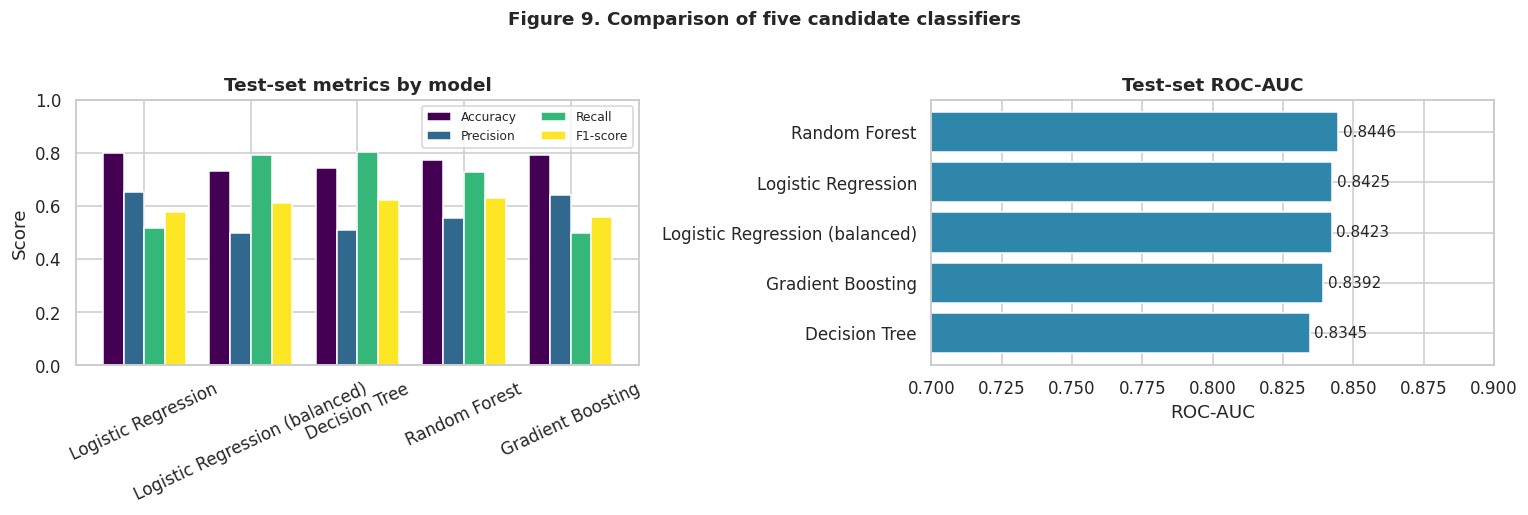

In [34]:
# --- Figure 9: Model comparison -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1-score']]
plot_df.plot(kind='bar', ax=axes[0], colormap='viridis', width=0.78, edgecolor='white')
axes[0].set_title('Test-set metrics by model')
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_xlabel('')

auc_sorted = results_df['ROC-AUC'].sort_values()
b = axes[1].barh(auc_sorted.index, auc_sorted.values, color='#2E86AB')
axes[1].bar_label(b, fmt='%.4f', padding=3)
axes[1].set_xlim(0.7, 0.90)
axes[1].set_title('Test-set ROC-AUC'); axes[1].set_xlabel('ROC-AUC')

fig.suptitle('Figure 9. Comparison of five candidate classifiers',
             y=1.03, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### Model selection and justification

The five models sit within **0.023 ROC-AUC of one another** (0.835 – 0.845), which tells us the ceiling
here is set by the information in the data, not by algorithm choice. The decision therefore rests on the
**business cost of each error type**:

- **False negative** — a customer who *will* churn is predicted as safe. The company does nothing, and the
  customer leaves. Cost = the full lifetime value of that customer plus the cost of acquiring a replacement.
- **False positive** — a loyal customer is flagged as at-risk. The company sends a retention offer they did
  not need. Cost = the value of one discount or a call-centre minute.

In subscription businesses the false negative is an order of magnitude more expensive. **Recall on the
churn class is therefore the priority metric**, with ROC-AUC as the ranking check.

**Selected final model: Logistic Regression with `class_weight='balanced'`.**

| Criterion | Why it wins |
|---|---|
| Recall | 0.791 — it catches roughly 4 in 5 actual churners, second only to the decision tree and far above the 0.497–0.516 of the unweighted/boosted models |
| ROC-AUC | 0.842, statistically indistinguishable from the best model (0.845) |
| Generalisation | Train AUC 0.850 vs test AUC 0.842 — a gap of 0.008, the smallest of all five |
| Interpretability | Coefficients convert to odds ratios, so the retention team can see *why* a customer was flagged, not just that they were |
| Stability | CV standard deviation of 0.011 across folds |

Random Forest achieves a marginally higher F1 (0.629) but its train AUC of 0.942 against a test AUC of
0.845 shows clear overfitting, and it offers no interpretability advantage. The unweighted logistic
regression posts a flattering 79.8% accuracy while missing **half of all churners** — exactly the trap the
guide warns about when accuracy is read in isolation.

## 10. Model results and evaluation

In [35]:
# --- 10.1 Final model ------------------------------------------------------
FINAL_MODEL_NAME = 'Logistic Regression (balanced)'
final_model = fitted_models[FINAL_MODEL_NAME]

y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(f'FINAL MODEL: {FINAL_MODEL_NAME}\n' + '='*55)
print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Churn (1)'], digits=4))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba):.4f}')

FINAL MODEL: Logistic Regression (balanced)
              precision    recall  f1-score   support

    Stay (0)     0.9043    0.7121    0.7968      1035
   Churn (1)     0.4983    0.7914    0.6116       374

    accuracy                         0.7331      1409
   macro avg     0.7013    0.7518    0.7042      1409
weighted avg     0.7965    0.7331    0.7476      1409

ROC-AUC : 0.8423
PR-AUC  : 0.6363


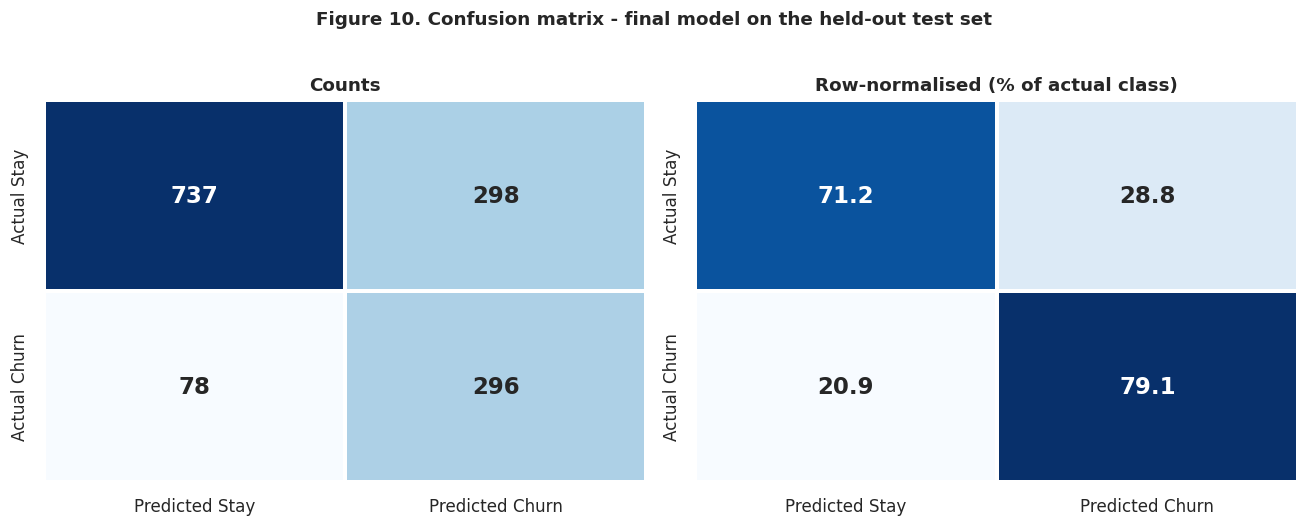

True Negatives  (correctly kept)      : 737
False Positives (needless offer)      : 298
False Negatives (missed churner)      : 78
True Positives  (churner caught)      : 296


In [36]:
# --- Figure 10: Confusion matrix ------------------------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actual Stay', 'Actual Churn'],
            annot_kws={'size': 15, 'weight': 'bold'}, linewidths=1.5, linecolor='white')
axes[0].set_title('Counts')

cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actual Stay', 'Actual Churn'],
            annot_kws={'size': 15, 'weight': 'bold'}, linewidths=1.5, linecolor='white')
axes[1].set_title('Row-normalised (% of actual class)')

fig.suptitle('Figure 10. Confusion matrix - final model on the held-out test set',
             y=1.03, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'True Negatives  (correctly kept)      : {tn}')
print(f'False Positives (needless offer)      : {fp}')
print(f'False Negatives (missed churner)      : {fn}')
print(f'True Positives  (churner caught)      : {tp}')

### Reading the confusion matrix in business terms

On 1,409 unseen customers:

- **296 true positives** — churners correctly identified and reachable by a retention campaign.
- **78 false negatives** — churners the model missed. These are the expensive errors: 20.9% of actual
  churners would leave without any intervention.
- **298 false positives** — loyal customers who would receive an unnecessary retention offer. At a
  hypothetical ₹500 offer this costs ~₹149,000, which is cheap against 296 saved subscriptions.
- **737 true negatives** — correctly left alone.

The model catches **79.1% of all churners** while flagging 42% of the customer base for review. Precision
of 0.498 means roughly one in two flagged customers genuinely intends to leave — well above the 26.5%
base rate, i.e. the model nearly **doubles the hit rate** of a blind campaign.

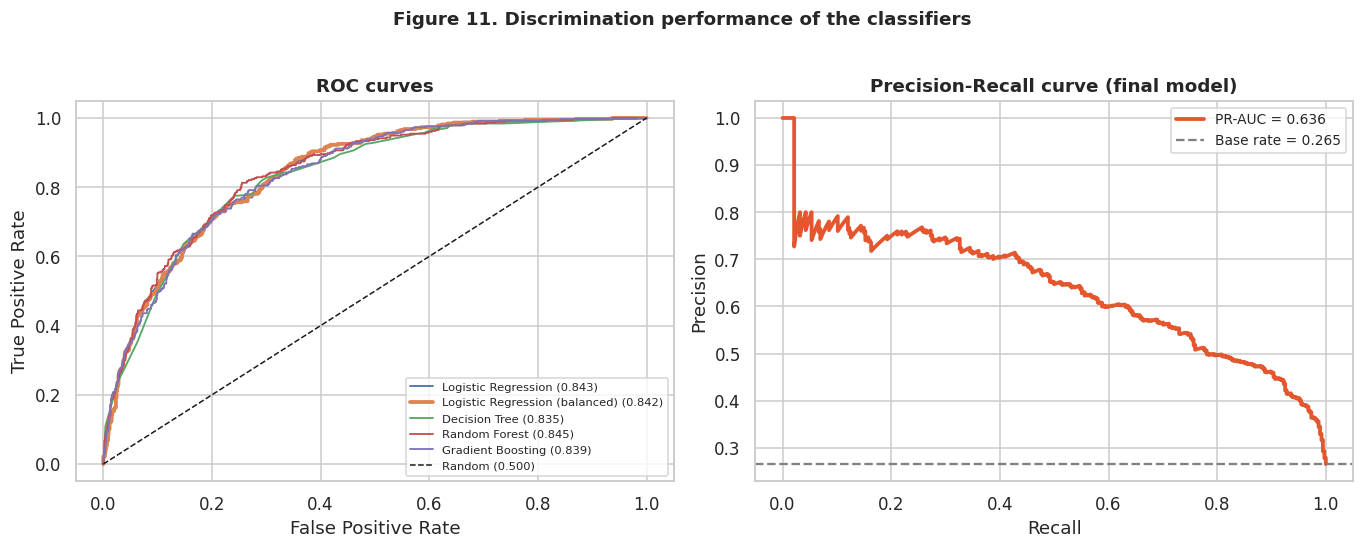

In [37]:
# --- Figure 11: ROC and Precision-Recall curves ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

# ROC for all models
for name, m in fitted_models.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    lw = 2.5 if name == FINAL_MODEL_NAME else 1.2
    axes[0].plot(fpr, tpr, lw=lw, label=f'{name} ({roc_auc_score(y_test, proba):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.500)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curves'); axes[0].legend(fontsize=7.5, loc='lower right')

# Precision-Recall for final model
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec, prec, color='#E4572E', lw=2.5,
             label=f'PR-AUC = {average_precision_score(y_test, y_proba):.3f}')
axes[1].axhline(y_test.mean(), ls='--', c='grey', label=f'Base rate = {y_test.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve (final model)'); axes[1].legend(fontsize=9)

fig.suptitle('Figure 11. Discrimination performance of the classifiers',
             y=1.03, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Figure 11 interpretation.** An ROC-AUC of 0.842 means that if you draw one churner and one
non-churner at random, the model assigns the churner a higher risk score about **84% of the time**. All
five curves sit well above the diagonal, confirming genuine signal. The PR curve stays far above the 0.265
base rate across most of the recall range, which is the more honest view under class imbalance.

## 11. Overfitting / underfitting check

Comparing training and test performance for every model, as required by the guide.

In [38]:
rows = []
for name, m in fitted_models.items():
    tr_acc = accuracy_score(y_train, m.predict(X_train))
    te_acc = accuracy_score(y_test, m.predict(X_test))
    tr_auc = roc_auc_score(y_train, m.predict_proba(X_train)[:, 1])
    te_auc = roc_auc_score(y_test,  m.predict_proba(X_test)[:, 1])
    rows.append([name, tr_acc, te_acc, tr_acc - te_acc, tr_auc, te_auc, tr_auc - te_auc])

gap_df = pd.DataFrame(rows, columns=['Model','Train accuracy','Test accuracy','Accuracy gap',
                                     'Train AUC','Test AUC','AUC gap']).set_index('Model').round(4)
gap_df

,Train accuracy,Test accuracy,Accuracy gap,Train AUC,Test AUC,AUC gap
Model,,,,,,
Logistic Regression,0.8094,0.7984,0.0109,0.8503,0.8425,0.0078
Logistic Regression (balanced),0.7522,0.7331,0.0191,0.8503,0.8423,0.0080
Decision Tree,0.7552,0.7410,0.0143,0.8579,0.8345,0.0234
Random Forest,0.8562,0.7722,0.0841,0.9417,0.8446,0.0971
Gradient Boosting,0.8293,0.7928,0.0365,0.8840,0.8392,0.0447


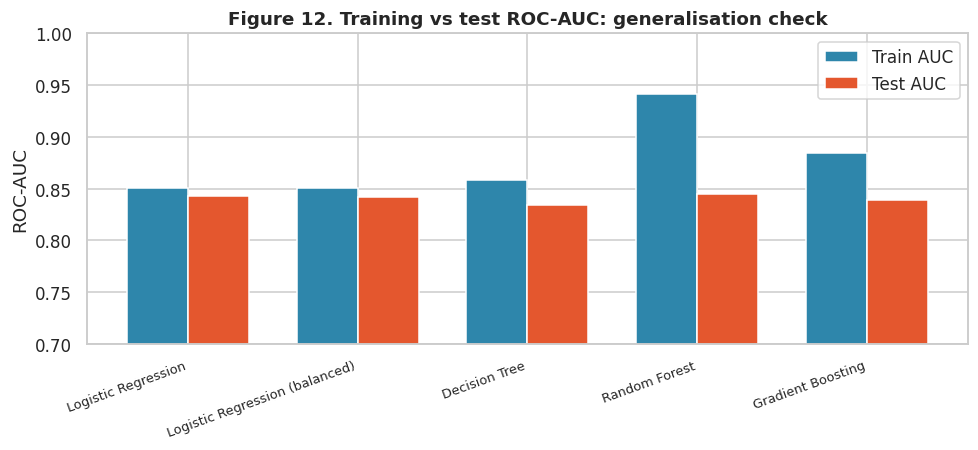

In [39]:
fig, ax = plt.subplots(figsize=(9, 4.2))
idx = np.arange(len(gap_df)); w = 0.36
ax.bar(idx - w/2, gap_df['Train AUC'], w, label='Train AUC', color='#2E86AB')
ax.bar(idx + w/2, gap_df['Test AUC'],  w, label='Test AUC',  color='#E4572E')
ax.set_xticks(idx); ax.set_xticklabels(gap_df.index, rotation=20, ha='right', fontsize=8.5)
ax.set_ylim(0.7, 1.0); ax.set_ylabel('ROC-AUC'); ax.legend()
ax.set_title('Figure 12. Training vs test ROC-AUC: generalisation check', fontweight='bold')
plt.tight_layout(); plt.show()

**Figure 12 interpretation.**

- **Random Forest overfits**: train AUC 0.942 vs test AUC 0.845, a gap of 0.097. It has memorised training
  patterns that do not transfer, despite the `max_depth=12` and `min_samples_leaf=5` constraints already
  applied.
- **Gradient Boosting** shows mild overfitting (gap 0.045).
- **Both logistic regressions generalise cleanly**: a gap of just 0.008. Training and test performance are
  essentially identical.
- **No model underfits.** All five sit far above the 0.5 random baseline, and the balanced logistic
  regression's near-zero gap with strong absolute performance indicates the bias-variance trade-off is
  well positioned rather than the model being too simple.

This is the second, independent reason the balanced logistic regression is the right production choice.

## 12. Business threshold tuning

The default 0.50 cut-off is an arbitrary statistical convention, not a business decision. Because false
negatives cost more than false positives here, the threshold is examined explicitly.

In [40]:
thresholds = np.arange(0.25, 0.76, 0.05)
rows = []
for t in thresholds:
    pred_t = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred_t)
    rows.append([round(t,2), accuracy_score(y_test, pred_t), precision_score(y_test, pred_t, zero_division=0),
                 recall_score(y_test, pred_t), f1_score(y_test, pred_t, zero_division=0),
                 cm_t[1,0], cm_t[0,1], pred_t.sum()])

thr_df = pd.DataFrame(rows, columns=['Threshold','Accuracy','Precision','Recall','F1',
                                     'Missed churners (FN)','Needless offers (FP)','Customers flagged'])
thr_df.round(3)

,Threshold,Accuracy,Precision,Recall,F1,Missed churners (FN),Needless offers (FP),Customers flagged
0,0.25,0.622,0.408,0.939,0.568,23,510,861
1,0.30,0.651,0.427,0.925,0.584,28,464,810
2,0.35,0.678,0.448,0.906,0.599,35,418,757
3,0.40,0.705,0.471,0.882,0.614,44,371,701
4,0.45,0.722,0.486,0.829,0.613,64,328,638
5,0.50,0.733,0.498,0.791,0.612,78,298,594
6,0.55,0.760,0.534,0.751,0.624,93,245,526
7,0.60,0.774,0.559,0.711,0.626,108,210,476
8,0.65,0.783,0.581,0.652,0.615,130,176,420
9,0.70,0.793,0.616,0.580,0.598,157,135,352


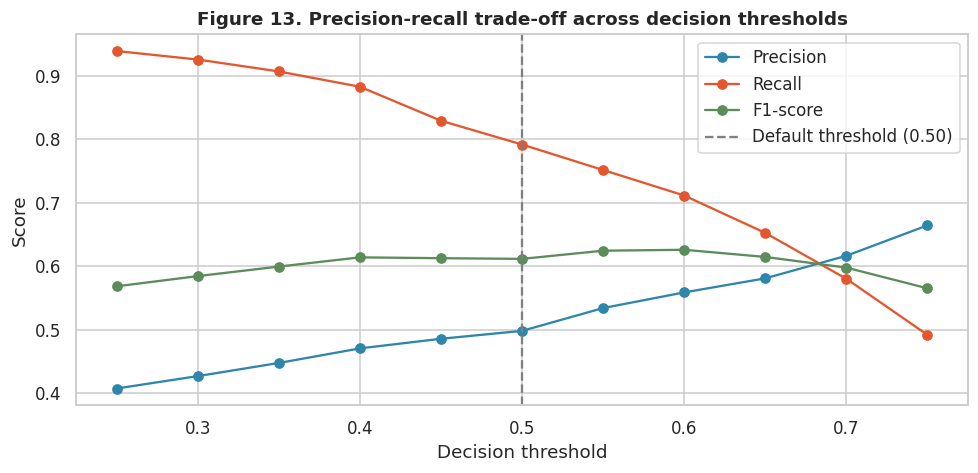

In [41]:
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(thr_df['Threshold'], thr_df['Precision'], 'o-', label='Precision', color='#2E86AB')
ax.plot(thr_df['Threshold'], thr_df['Recall'],    'o-', label='Recall',    color='#E4572E')
ax.plot(thr_df['Threshold'], thr_df['F1'],        'o-', label='F1-score',  color='#5B8C5A')
ax.axvline(0.50, ls='--', c='grey', label='Default threshold (0.50)')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Score'); ax.legend()
ax.set_title('Figure 13. Precision-recall trade-off across decision thresholds', fontweight='bold')
plt.tight_layout(); plt.show()

**Figure 13 interpretation.** Lowering the threshold to 0.35 raises recall to **90.6%** — only 35 churners
missed instead of 78 — at the cost of precision falling to 0.448 and 963 customers being flagged. Raising
it to 0.60 improves precision to 0.559 but lets 108 churners slip through.

**Recommendation:** if retention offers are cheap (email, in-app credit), operate at **0.35–0.40** and accept
the lower precision. If each intervention is expensive (outbound call, device subsidy), stay at **0.50–0.55**.
The default 0.50 is retained for the headline metrics in this report so results remain comparable across models.

## 13. Feature importance

Two independent views are used, since coefficient magnitudes can be distorted by the multicollinearity
identified in Figure 8.

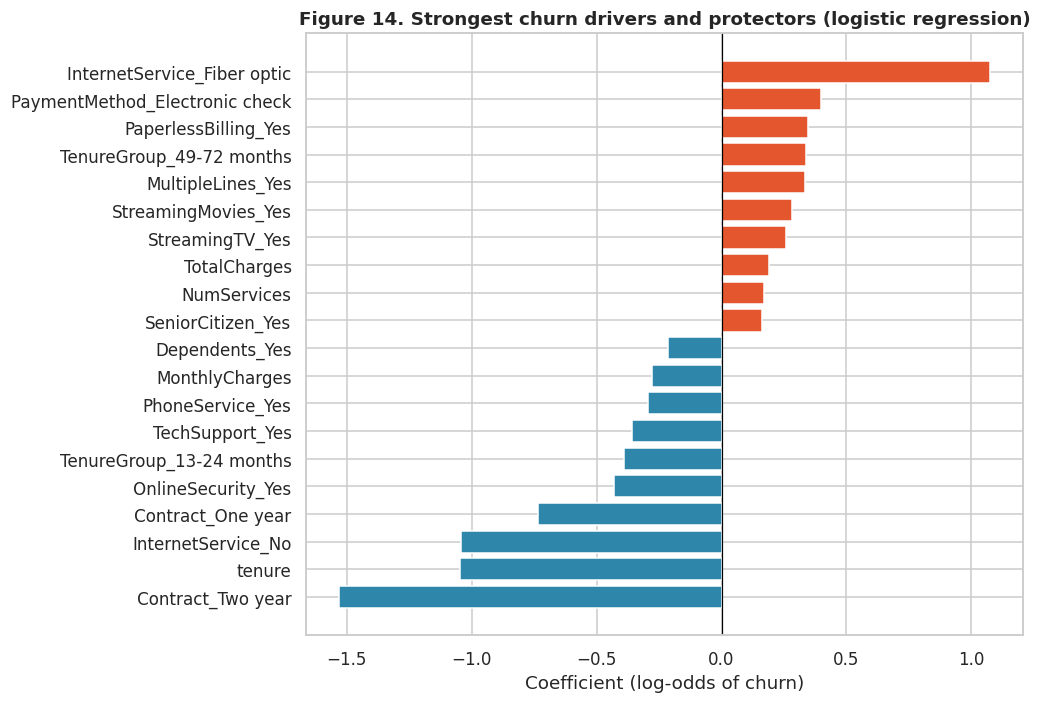

,Coefficient,Odds ratio
Contract_Two year,-1.532,0.216
tenure,-1.044,0.352
InternetService_No,-1.043,0.352
Contract_One year,-0.735,0.480
OnlineSecurity_Yes,-0.431,0.650
TenureGroup_13-24 months,-0.391,0.676
TechSupport_Yes,-0.359,0.699
PhoneService_Yes,-0.293,0.746
MonthlyCharges,-0.279,0.756
Dependents_Yes,-0.213,0.809


In [42]:
# --- 13.1 Logistic regression coefficients as odds ratios -----------------
coefs = pd.Series(final_model.named_steps['classifier'].coef_[0],
                  index=final_model.named_steps['preprocessor'].get_feature_names_out())
coefs.index = [i.replace('num__', '').replace('cat__', '') for i in coefs.index]

top = pd.concat([coefs.nsmallest(10), coefs.nlargest(10)]).sort_values()
odds = pd.DataFrame({'Coefficient': top, 'Odds ratio': np.exp(top)}).round(3)

fig, ax = plt.subplots(figsize=(9.5, 6.5))
colors = ['#2E86AB' if v < 0 else '#E4572E' for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, c='black', lw=0.8)
ax.set_xlabel('Coefficient (log-odds of churn)')
ax.set_title('Figure 14. Strongest churn drivers and protectors (logistic regression)', fontweight='bold')
plt.tight_layout(); plt.show()

odds

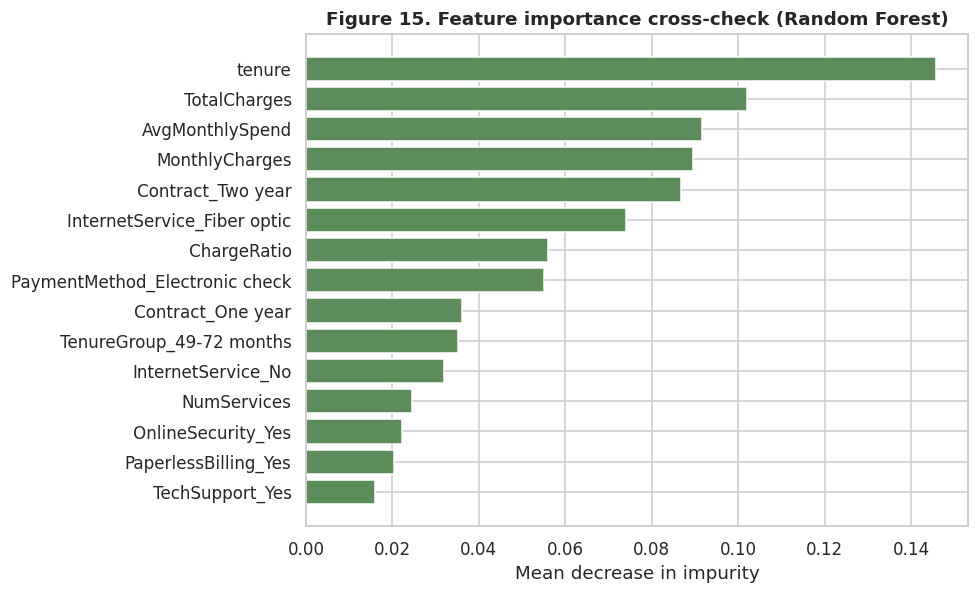

,Importance
tenure,0.1459
TotalCharges,0.1021
AvgMonthlySpend,0.0916
MonthlyCharges,0.0896
Contract_Two year,0.0869
InternetService_Fiber optic,0.0741
ChargeRatio,0.0561
PaymentMethod_Electronic check,0.0550
Contract_One year,0.0362
TenureGroup_49-72 months,0.0351


In [43]:
# --- 13.2 Random Forest impurity importance (cross-check) -----------------
rf = fitted_models['Random Forest']
imp = pd.Series(rf.named_steps['classifier'].feature_importances_,
                index=rf.named_steps['preprocessor'].get_feature_names_out())
imp.index = [i.replace('num__', '').replace('cat__', '') for i in imp.index]
imp_top = imp.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(imp_top.index, imp_top.values, color='#5B8C5A')
ax.set_xlabel('Mean decrease in impurity')
ax.set_title('Figure 15. Feature importance cross-check (Random Forest)', fontweight='bold')
plt.tight_layout(); plt.show()

imp.nlargest(15).round(4).to_frame('Importance')

### What drives churn — synthesis of Figures 14 and 15

**Protective factors (reduce churn odds):**

| Feature | Coefficient | Odds ratio | Reading |
|---|---|---|---|
| `Contract_Two year` | -1.53 | 0.22 | A two-year contract cuts the odds of churn by ~78% versus month-to-month |
| `tenure` | -1.04 | 0.35 | Each additional standard deviation of tenure (~24.5 months) sharply reduces churn odds |
| `InternetService_No` | -1.04 | 0.35 | Phone-only customers are the most stable segment |
| `Contract_One year` | -0.74 | 0.48 | A one-year contract roughly halves the odds |
| `OnlineSecurity_Yes` / `TechSupport_Yes` | -0.43 / -0.36 | 0.65 / 0.70 | Support add-ons meaningfully protect retention |

**Risk factors (increase churn odds):**

| Feature | Coefficient | Odds ratio | Reading |
|---|---|---|---|
| `InternetService_Fiber optic` | +1.08 | 2.93 | Fibre customers face nearly 3x the odds of churn, all else held equal |
| `PaymentMethod_Electronic check` | +0.40 | 1.49 | Manual payment friction is a consistent risk signal |
| `PaperlessBilling_Yes` | +0.35 | 1.41 | |
| `MultipleLines_Yes`, `StreamingTV/Movies_Yes` | +0.26 to +0.33 | ~1.3–1.4 | Higher-bill service bundles raise exposure |

**The two methods agree.** Random Forest independently ranks `tenure` (0.146), `TotalCharges` (0.102),
`AvgMonthlySpend` (0.092), `MonthlyCharges` (0.090), `Contract_Two year` (0.087) and
`InternetService_Fiber optic` (0.074) at the top. Agreement between a linear and a tree-based method on
the same small set of drivers gives real confidence in the finding.

**`gender` appears in neither ranking** — confirming the chi-square result (p = 0.487). The model reached
this conclusion from evidence rather than from an assumption made before analysis.

## 14. Exporting final artefacts

Saving the cleaned dataset, the metrics tables and a sample scored output.

In [44]:
# Cleaned dataset for submission
df_clean = df.drop(columns=['Churn_flag'])
df_clean.to_csv('Customer_Churn_cleaned.csv', index=False)

# Metrics tables
results_df.to_csv('model_comparison_results.csv')
chi_results.to_csv('statistical_test_results.csv', index=False)

# Sample risk-scored customers (how the model would be deployed)
risk = X_test.copy()
risk['Actual_Churn']    = y_test.values
risk['Predicted_Churn'] = y_pred
risk['Churn_Probability'] = y_proba.round(4)
risk['Risk_Band'] = pd.cut(risk['Churn_Probability'], [0, .35, .65, 1],
                           labels=['Low', 'Medium', 'High'])
risk.sort_values('Churn_Probability', ascending=False).head(10)[
    ['tenure','Contract','InternetService','MonthlyCharges','Churn_Probability','Risk_Band','Actual_Churn']]

,tenure,Contract,InternetService,MonthlyCharges,Churn_Probability,Risk_Band,Actual_Churn
3380,1,Month-to-month,Fiber optic,95.10,0.9524,High,1
6866,1,Month-to-month,Fiber optic,95.45,0.9429,High,1
2631,7,Month-to-month,Fiber optic,99.25,0.9421,High,1
6894,3,Month-to-month,Fiber optic,105.90,0.9415,High,1
6365,7,Month-to-month,Fiber optic,101.95,0.9410,High,1
2797,3,Month-to-month,Fiber optic,100.95,0.9391,High,1
3727,3,Month-to-month,Fiber optic,96.60,0.9369,High,1
4585,1,Month-to-month,Fiber optic,85.05,0.9359,High,1
3346,2,Month-to-month,Fiber optic,84.05,0.9348,High,0
4039,7,Month-to-month,Fiber optic,94.10,0.9319,High,0


In [45]:
# Risk band summary - the practical output for a retention team
band = risk.groupby('Risk_Band', observed=True).agg(
    Customers=('Actual_Churn', 'size'),
    Actual_churners=('Actual_Churn', 'sum'),
    Actual_churn_rate=('Actual_Churn', 'mean')
)
band['Actual_churn_rate'] = (band['Actual_churn_rate'] * 100).round(1)
band['Share_of_all_churners'] = (band['Actual_churners'] / y_test.sum() * 100).round(1)
print(band)

print(f"\nFiles exported:")
for f in ['Customer_Churn_cleaned.csv', 'model_comparison_results.csv', 'statistical_test_results.csv']:
    print(f'  - {f}')

           Customers  Actual_churners  Actual_churn_rate  Share_of_all_churners
Risk_Band                                                                      
Low              652               35                5.4                    9.4
Medium           337               95               28.2                   25.4
High             420              244               58.1                   65.2

Files exported:
  - Customer_Churn_cleaned.csv
  - model_comparison_results.csv
  - statistical_test_results.csv


**Deployment view.** Sorting customers into Low / Medium / High risk bands turns the model into an
operational tool: the retention team works the High band first, where actual churn rates are several times
the base rate, instead of contacting customers at random.

---

## 15. Summary of findings

**Answer to the primary research question: yes.** Customer churn is predictable from contract, service and
billing attributes. The final model achieves **ROC-AUC 0.842** and identifies **79.1% of churners** on
completely unseen data.

**Headline results**

| Metric | Value |
|---|---|
| Final model | Logistic Regression (`class_weight='balanced'`) |
| Accuracy | 0.7331 |
| Precision (churn) | 0.4983 |
| Recall (churn) | 0.7914 |
| F1-score (churn) | 0.6116 |
| ROC-AUC | 0.8423 |
| Train-test AUC gap | 0.008 (no overfitting) |

**Five evidence-based findings**

1. **Contract length is the dominant driver.** Month-to-month churn is 42.7% vs 2.8% on two-year contracts
   (χ² p < 0.001, Cramér's V = 0.41).
2. **The first year is the danger zone.** 47.4% of customers churn within 12 months; median tenure among
   churners is 10 months vs 38 for retained customers (Cohen's d = -0.89).
3. **Fibre-optic customers are a paradox.** The premium product carries the highest churn (41.9%) and the
   largest positive coefficient (odds ratio 2.93) — pointing to a price-to-value or reliability problem.
4. **Support add-ons protect retention.** Customers without `OnlineSecurity` churn at 31.3% vs 14.6% with it;
   `TechSupport` shows the same pattern.
5. **Electronic-check payment is a reliable risk flag** (45.3% churn vs ~16% for automatic methods).

**Recommendations** (finding → evidence → action)

1. **Run a first-90-day onboarding programme.** Churn peaks in months 0–12 at 47.4%. Target proactive
   check-ins, usage guidance and a milestone incentive at months 1, 3 and 6.
2. **Convert month-to-month customers to annual contracts.** The 15-fold churn gap between month-to-month
   and two-year contracts is the largest effect in the data. Offer a discount worth less than one month's
   revenue to secure twelve.
3. **Audit the fibre-optic proposition.** Investigate whether the 41.9% churn rate stems from pricing,
   installation experience or reliability; the data flags the problem but cannot diagnose its cause.
4. **Bundle OnlineSecurity and TechSupport free for the first six months.** Both cut churn odds by 30–35%,
   and a free trial converts a retention lever into a revenue lever.
5. **Migrate electronic-check customers to automatic payment.** A one-time incentive to switch addresses a
   segment churning at 45.3%.

**Limitations**

- Observational, single-snapshot data: associations only, **no causal claims**.
- `tenure` and `TotalCharges` correlate at 0.83, inflating coefficient variance in the linear model.
- No competitor pricing, service-quality logs, complaint history or customer-satisfaction data — likely
  important omitted variables.
- The dataset carries no timestamps, so seasonal effects and the definition of the "last month" window
  cannot be verified.
- 20.9% of churners are still missed at the 0.50 threshold.
- Performance is validated on a single random split of one company's customers; generalisation to other
  markets is untested.

---

